In [1]:
import tensorflow as tf
from tensorflow import keras
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
import pandas as pd

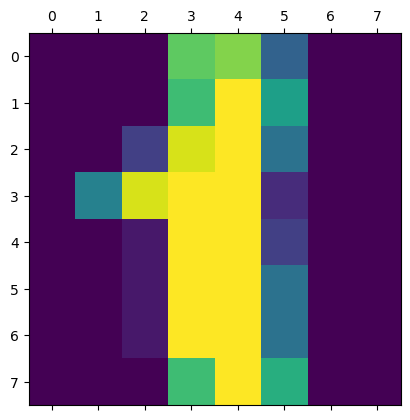

In [2]:
digits=datasets.load_digits()
plt.matshow(digits.images[1])

In [3]:
inputs=pd.DataFrame(digits.data,columns=digits.feature_names)
target=digits.target

In [4]:
X_train, X_test, y_train, y_test = train_test_split(inputs,target,test_size=0.2)

In [5]:
model=keras.Sequential([
    keras.layers.Flatten(input_shape=(64,)),
    keras.layers.Dense(200, activation='relu'),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
              metrics= ['accuracy']
             )

tb_callback=keras.callbacks.TensorBoard(log_dir='logs/', histogram_freq=1)
# Write this in cmd [ python -m tensorboard.main --logdir="C:\Users\samag\OneDrive\Desktop\ML\Deep Learning Exercise\logs" ]

model.fit(X_train, y_train, epochs=5, callbacks=[tb_callback])

C:\Users\samag\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7251 - loss: 0.9740
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9499 - loss: 0.1587
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9812 - loss: 0.0771
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9889 - loss: 0.0495
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9910 - loss: 0.0363


In [6]:
import seaborn as sn
from sklearn.metrics import confusion_matrix

predictions=model.predict(X_test)
y_predictions=np.argmax(predictions, axis=1)
cm=confusion_matrix(y_test, y_predictions)
cm

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


array([[37,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 34,  0,  0,  0,  0,  0,  0,  2,  0],
       [ 0,  0, 36,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 30,  0,  1,  0,  0,  2,  0],
       [ 0,  0,  0,  0, 43,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 32,  1,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 41,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 39,  0,  0],
       [ 0,  0,  0,  1,  0,  1,  0,  0, 24,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  1, 35]])

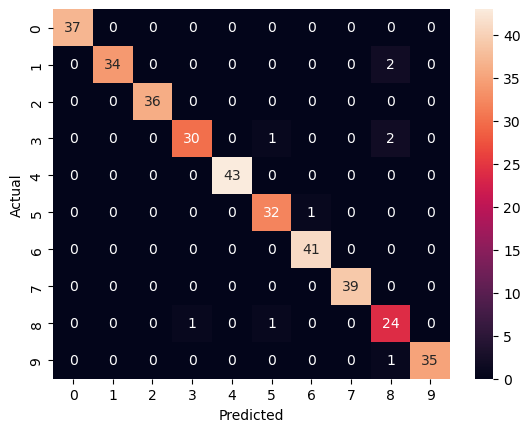

In [7]:
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()